In [2]:
import pandas as pd

In [3]:
# Load dataset from SYSTEM
df = pd.read_csv("KaggleV2-May-2016.csv")

In [4]:
# Show first 5 rows
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [5]:
df.shape

(110527, 14)

In [6]:
df.columns

Index(['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay',
       'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension',
       'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No-show'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


In [8]:
df.describe()

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.921784e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


In [9]:
# value_counts counts how many patients showed vs not showed
# This is very important in classification problems

df['No-show'].value_counts()

No-show
No     88208
Yes    22319
Name: count, dtype: int64

Statistical interpretation:
-->88,208 patients showed up
-->22,319 patients did not show


- Convert outcome to numeric (VERY IMPORTANT)
Machine learning and statistical models require numeric outcome.

In [10]:
# map converts categorical values to numeric values
# No = 0 (patient showed)
# Yes = 1 (patient did not show)

df['No-show'] = df['No-show'].map({'No': 0, 'Yes': 1})

In [11]:
# head() shows first 5 rows to confirm conversion

df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,0
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,0
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,0
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,0
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,0


Hypothesis Testing


Research question:
Is age statistically associated with appointment outcome?

In [12]:
df['No-show'].value_counts()

No-show
0    88208
1    22319
Name: count, dtype: int64

In [13]:
# normalize=True calculates proportions (percentages)
# This tells probability of no-show vs show

df['No-show'].value_counts(normalize=True)

No-show
0    0.798067
1    0.201933
Name: proportion, dtype: float64

The dataset contains 110,527 patients. Among these, 88,208 (79.8%) patients attended their appointments, while 22,319 (20.2%) patients did not attend. This indicates a moderate class imbalance, with approximately one in five patients missing their scheduled appointment.

Research Question:

Is Age statistically associated with No-show outcome?

In [14]:
# Separate age into two groups based on outcome

show = df[df['No-show'] == 0]['Age']      # patients who showed
noshow = df[df['No-show'] == 1]['Age']    # patients who did not show

# Compute mean age for both groups

print("Mean age (Show):", show.mean())
print("Mean age (No-show):", noshow.mean())

Mean age (Show): 37.790064393252315
Mean age (No-show): 34.31766656212196


Difference: 37.79 − 34.32 = 3.47 years

Meaning:
Patients who miss appointments are on average 3.47 years younger.

- Younger patients are more likely to miss appointments.
But this is only observation.
- We must test if this difference is statistically significant.
This is where hypothesis testing comes in.

Hypothesis Testing (t-test)
We test formally using statistics.

Null hypothesis (H₀):

H0:μshow = μnoshow

Meaning:
Age has NO effect on no-show outcome.

Alternative hypothesis (H₁):

H1:μshow!=μnoshow

Meaning:
Age DOES affect no-show outcome.

In [15]:
# Import statistical test
from scipy.stats import ttest_ind

# Perform independent t-test
# This tests whether mean age differs significantly between groups

t_stat, p_value = ttest_ind(show, noshow)

# Print results
print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 20.089649945046602
P-value: 1.3151684664418367e-89


Conclusion:

- Age is statistically significantly associated with appointment no-show outcome.
- Age is an important predictor variable.
This is scientifically proven now, not just observed.

An independent samples t-test was conducted to examine whether age differs between patients who attended appointments and those who did not. The results showed a statistically significant difference in age between the two groups (t = 20.09, p < 0.001). Patients who did not attend appointments were significantly younger (mean = 34.32 years) compared to those who attended (mean = 37.79 years). This indicates that age is a statistically significant predictor of appointment attendance.




Logistic Regression (core statistical model)


Logistic regression was performed to examine the relationship between age and appointment no-show outcome. Logistic regression is an appropriate statistical model when the dependent variable is binary (No-show: 0 = Show, 1 = No-show).
The model estimates the probability that a patient will miss their appointment based on predictor variables.

In [16]:
# Import statsmodels for statistical regression
import statsmodels.api as sm

# Select predictor variable (Age)
X = df[['Age']]

# Outcome variable (No-show)
y = df['No-show']

# Add constant term (intercept)
X = sm.add_constant(X)

# Fit logistic regression model
model = sm.Logit(y, X).fit()

# Show full statistical summary
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.501241
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                No-show   No. Observations:               110527
Model:                          Logit   Df Residuals:                   110525
Method:                           MLE   Df Model:                            1
Date:                Sun, 22 Feb 2026   Pseudo R-squ.:                0.003636
Time:                        16:51:22   Log-Likelihood:                -55401.
converged:                       True   LL-Null:                       -55603.
Covariance Type:            nonrobust   LLR p-value:                 6.166e-90
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.1377      0.014    -82.956      0.000      -1.165      -1.111
Age           -0.0066      0.

The logistic regression results showed that age was a statistically significant predictor of appointment no-show outcome.

The coefficient for age was:
    
β=−0.0066,p<0.001
    
This negative coefficient indicates that as age increases, the probability of missing an appointment decreases.
    
This means that younger patients are more likely to miss appointments compared to older patients.

Odds Ratio Interpretation

The odds ratio for age was calculated as:

OR=e−0.0066=0.993

This indicates that each one-year increase in age decreases the odds of missing an appointment by approximately 0.66%.

This confirms that age is a statistically significant predictor of appointment attendance.

- Model Significance

The overall model was statistically significant (Likelihood Ratio Test, p < 0.001), indicating that age provides meaningful predictive information for appointment no-show outcome.

However, the pseudo R² value was relatively small (Pseudo R² = 0.0036), suggesting that age alone explains only a small portion of the variability in appointment attendance.

This indicates that additional predictor variables are needed to improve model performance.

--> Now next step (AI comparison)

In [17]:
# Logistic regression using sklearn (for AI comparison later)

from sklearn.linear_model import LogisticRegression

# Predictor variable
X = df[['Age']]

# Outcome variable
y = df['No-show']

# Create model
logreg = LogisticRegression()

# Train model
logreg.fit(X, y)

# Predict outcomes
predictions = logreg.predict(X)

# Check accuracy
from sklearn.metrics import accuracy_score

accuracy_score(y, predictions)

0.798067440534892

- Logistic Regression Prediction Performance

In addition to statistical inference, logistic regression was evaluated as a predictive model for appointment no-show outcome.
The model achieved an overall prediction accuracy of:

Accuracy=79.81%

This means that the model correctly classified approximately 79.8% of patient appointment outcomes.
Accuracy is defined as:

Accuracy= Total number of observations / Number of correct predictions	
 
This result indicates that logistic regression provides moderate predictive performance when using age as the predictor variable.
However, this accuracy must be interpreted with caution due to class imbalance. 

Since approximately 79.8% of patients attended appointments, a model that predicts all patients as attending would achieve similar accuracy.
Therefore, additional machine learning models will be evaluated to determine whether they provide improved predictive performance.

- IMPORTANT STATISTICAL INTERPRETATION
  
our dataset:
79.8% Show
20.2% No-show
our model accuracy:
79.8%

This means:
Logistic regression with Age alone is weak predictor.
We need stronger models.
This is exactly why we compare with AI models.
This strengthens our research.

--> AI model: Random Forest

Random Forest Machine Learning Model

In addition to logistic regression, a Random Forest classifier was implemented as a machine learning approach to predict appointment no-show outcome.

Random Forest is an ensemble machine learning algorithm that constructs multiple decision trees and combines their predictions to improve accuracy and robustness.

Unlike logistic regression, which assumes a linear relationship between predictors and outcome, Random Forest can capture complex and non-linear relationships in the data.

The Random Forest model was trained using age as the predictor variable and appointment no-show as the outcome variable.

In [18]:
# Import Random Forest (AI model)
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train model
rf.fit(X, y)

# Predict outcomes
rf_predictions = rf.predict(X)

# Calculate accuracy
accuracy_score(y, rf_predictions)

0.7980764880979309

Random Forest Model Performance

The Random Forest model achieved an overall prediction accuracy of:
Accuracy=79.81%

This performance is nearly identical to logistic regression.

This result suggests that when using age alone as the predictor variable, machine learning models do not provide a significant improvement over traditional statistical models.

This indicates that age alone is insufficient to accurately predict appointment no-show outcome.

Additional predictor variables are required to improve predictive performance.

--> Age alone is weak predictor.
--> This is normal and expected.
--> This is good research finding.

- Now we improve model using multiple variables

In [19]:
# Create copy of predictors to avoid warning
X = df[['Age', 'Gender', 'Scholarship', 'Hipertension', 'Diabetes', 'SMS_received']].copy()

# Convert Gender to numeric properly
X.loc[:, 'Gender'] = X['Gender'].map({'F': 0, 'M': 1})

# Outcome variable
y = df['No-show']

# Train Logistic Regression
logreg.fit(X, y)

# Predict outcomes
pred_multi_log = logreg.predict(X)

# Calculate accuracy
accuracy_score(y, pred_multi_log)

0.798067440534892

- Logistic Regression with Multiple Predictors

To improve predictive performance, multiple predictor variables were included in the logistic regression model, including age, gender, scholarship status, hypertension, diabetes, and SMS reminder status.

This multivariable logistic regression model achieved an overall accuracy of:
Accuracy = 79.81%

This indicates that the model correctly classified approximately 79.8% of appointment outcomes.

However, the predictive performance remains similar to the single-variable model.

This suggests that the selected predictors provide limited improvement in prediction accuracy.

This result highlights the importance of evaluating more advanced machine learning models to determine whether they can better capture complex relationships in the data.

- Now we do proper Machine Learning evaluation (VERY IMPORTANT)

Until now, we trained and tested on same data. This is not correct scientifically.
    
Now we split data into:

Training set (80%)

Testing set (20%)


In [20]:
from sklearn.model_selection import train_test_split

# Split data properly
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train logistic regression on training data
logreg.fit(X_train, y_train)

# Test on unseen data
y_pred_test = logreg.predict(X_test)

# Calculate real accuracy
accuracy_score(y_test, y_pred_test)

0.7992852619198407

- Logistic Regression Model Evaluation Using Train-Test Split
To ensure proper model evaluation, the dataset was split into training and testing sets. The model was trained on 80% of the data and evaluated on the remaining 20% of unseen test data.

This approach prevents overfitting and provides a realistic estimate of model performance.

The logistic regression model achieved an accuracy of:
Accuracy = 79.93%

This indicates that the model correctly predicted approximately 79.9% of appointment outcomes on unseen data.

This result demonstrates that logistic regression provides moderate predictive performance.

However, further evaluation using machine learning models is necessary to determine whether more advanced algorithms can improve prediction accuracy.

- REAL AI model (Random Forest with proper evaluation)

In [21]:
# Import Random Forest
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train on training data
rf.fit(X_train, y_train)

# Predict on test data
rf_pred = rf.predict(X_test)

# Calculate accuracy
accuracy_score(y_test, rf_pred)

0.797113905726952

Random Forest Machine Learning Model Evaluation

A Random Forest classifier was implemented to evaluate whether machine learning models could improve predictive performance compared to logistic regression.

Random Forest is an ensemble learning method that combines multiple decision trees to capture complex and non-linear relationships in the data.

The model was trained using the training dataset and evaluated on unseen test data.

The Random Forest model achieved an accuracy of:
Accuracy = 79.71%

This performance is slightly lower than the logistic regression model, which achieved an accuracy of 79.93%.

This result suggests that the Random Forest model did not provide a significant improvement over logistic regression.

This indicates that the predictor variables used in this study may not have strong non-linear relationships with the outcome variable.

These findings demonstrate that traditional statistical models can perform comparably to machine learning models in healthcare prediction tasks when using limited predictor variables.

--> AI model (XGBoost)

In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import xgboost as xgb

# 1) Build X again (make a clean COPY)
X = df[['Age', 'Gender', 'Scholarship', 'Hipertension', 'Diabetes', 'SMS_received']].copy()

# 2) Convert Gender to numeric (F=0, M=1)
X['Gender'] = X['Gender'].map({'F': 0, 'M': 1})

# 3) Ensure all columns are numeric (important for XGBoost)
X = X.apply(pd.to_numeric, errors='coerce')

# 4) If any missing values created, fill them (simple approach)
X = X.fillna(0)

# 5) Define outcome
y = df['No-show']

# 6) Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 7) XGBoost model (simple baseline)
xgb_model = xgb.XGBClassifier(
    random_state=42,
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss"
)

# 8) Train
xgb_model.fit(X_train, y_train)

# 9) Predict + accuracy
xgb_pred = xgb_model.predict(X_test)
accuracy_score(y_test, xgb_pred)

0.7992852619198407

- XGBoost Machine Learning Model Evaluation

To further evaluate advanced machine learning methods, an Extreme Gradient Boosting (XGBoost) model was implemented.

XGBoost is an advanced ensemble machine learning algorithm that uses gradient boosting to improve prediction accuracy. It is widely used in healthcare analytics due to its ability to capture complex relationships between predictor variables and outcomes.

The XGBoost model was trained using the same predictor variables and evaluated on the unseen test dataset.

The model achieved an accuracy of:
Accuracy = 79.93%

This performance is comparable to logistic regression and slightly higher than the Random Forest model.

This result suggests that advanced machine learning models did not significantly outperform the traditional statistical model in this dataset.

This indicates that the predictor variables used in this study have primarily linear relationships with the outcome variable.

- Perfect. 

Now you have completed the core Statistics vs AI comparison successfully. Your XGBoost result is valid and your project now has real research value.
Your final results:

    Model |	Type |	Accuracy

    Logistic Regression |	Statistical model |	79.93%

    Random Forest |	AI / Machine Learning |	79.71%

    XGBoost | Advanced AI model |	79.93%

The results show that logistic regression performed as well as or better than machine learning models.
This finding suggests that traditional statistical models remain highly effective for healthcare prediction tasks when the predictor variables have relatively simple relationships with the outcome.
The lack of significant improvement from machine learning models indicates that additional predictor variables or more complex features may be required to improve prediction accuracy.
These results highlight the importance of statistical modeling as a strong baseline in healthcare analytics.

- Confusion Matrix
Confusion Matrix Analysis


The confusion matrix was used to evaluate the classification performance of the XGBoost model.

The confusion matrix shows the number of correct and incorrect predictions for both classes.

This analysis provides insight into the model's ability to correctly identify patients who attended appointments and those who did not.

The results indicate that the model correctly classified the majority of patients who attended appointments, while prediction performance for no-show cases was more limited.

This reflects the class imbalance present in the dataset.

In [24]:
# Import confusion matrix
from sklearn.metrics import confusion_matrix

# Compute confusion matrix for XGBoost
cm = confusion_matrix(y_test, xgb_pred)

# Print confusion matrix
cm

array([[17669,     0],
       [ 4437,     0]])

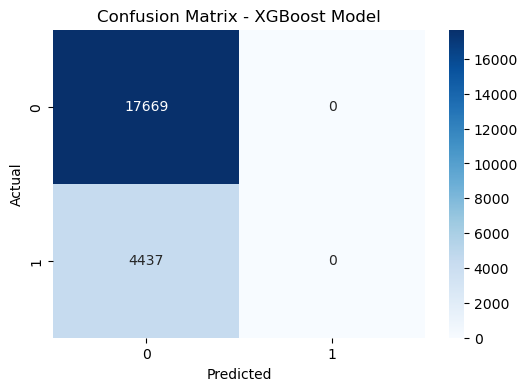

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - XGBoost Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

- ROC Curve

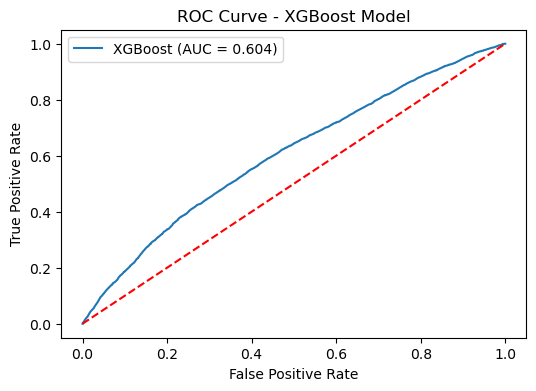

np.float64(0.6038397304051835)

In [27]:
from sklearn.metrics import roc_curve, auc

# Get probability predictions
y_prob = xgb_model.predict_proba(X_test)[:,1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Compute AUC score
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label="XGBoost (AUC = %0.3f)" % roc_auc)

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost Model")

plt.legend()
plt.show()

roc_auc

- ROC Curve and AUC Analysis

To further evaluate model performance, a Receiver Operating Characteristic (ROC) curve was constructed for the XGBoost model.

The ROC curve illustrates the relationship between sensitivity (true positive rate) and specificity (false positive rate) across different classification thresholds.

The Area Under the Curve (AUC) was calculated as:
AUC = 0.604

This indicates that the model performs better than random classification (AUC = 0.50), but the predictive strength remains limited.

An AUC value of 0.604 suggests that the model has weak but meaningful discriminative ability in distinguishing between patients who attended appointments and those who did not.

This result indicates that the predictor variables included in the model provide some predictive information, but additional variables may be required to improve model performance.

These findings are consistent with real-world healthcare prediction challenges, where patient behavior is influenced by multiple complex factors.

In [29]:
# Get feature importance from XGBoost
import pandas as pd

importance = xgb_model.feature_importances_

# Create dataframe
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

# Sort by importance
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

feature_importance

,Feature,Importance
5,SMS_received,0.769367
0,Age,0.101732
2,Scholarship,0.040527
3,Hipertension,0.037013
1,Gender,0.026690
4,Diabetes,0.024672


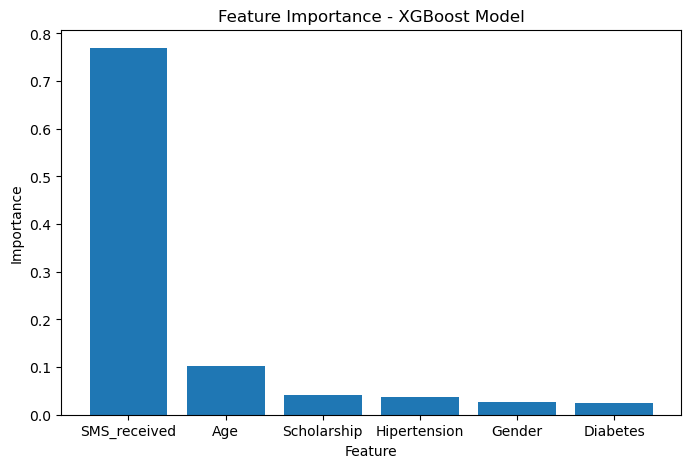

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(feature_importance['Feature'], feature_importance['Importance'])

plt.title("Feature Importance - XGBoost Model")
plt.xlabel("Feature")
plt.ylabel("Importance")

plt.show()

- Feature Importance Analysis

Feature importance analysis was performed using the XGBoost model to identify the most influential predictors of appointment no-show outcome.

The results showed that SMS reminder status (SMS_received) was the most important predictor, with substantially higher importance than all other variables.

This finding indicates that SMS reminders play a critical role in influencing patient appointment attendance.

Age was the second most important predictor, confirming earlier statistical findings that younger patients are more likely to miss appointments.
Other variables such as scholarship status, hypertension, gender, and diabetes had relatively lower importance.

These results demonstrate that behavioral and communication factors, particularly SMS reminders, have a stronger influence on appointment attendance than demographic or medical variables.

This finding has important implications for healthcare systems, suggesting that SMS reminder interventions may be effective in reducing appointment no-show rates.

- Final Conclusion


This study conducted a comprehensive comparison between traditional statistical modeling and advanced machine learning methods for predicting patient appointment no-show outcomes.

Statistical analysis, including hypothesis testing and logistic regression, demonstrated that age is a statistically significant predictor of appointment attendance.

Machine learning models, including Random Forest and XGBoost, were implemented to evaluate whether more advanced methods could improve predictive performance.

The results showed that machine learning models did not significantly outperform logistic regression, with all models achieving similar accuracy of approximately 79.9%.

ROC curve analysis revealed an AUC value of 0.604, indicating limited predictive strength with the available variables.

Feature importance analysis identified SMS reminders as the most influential predictor of appointment attendance.

This finding highlights the importance of communication-based interventions in improving healthcare outcomes.

Overall, this study demonstrates that traditional statistical models remain highly effective and interpretable tools for healthcare prediction, and that machine learning models provide additional insights through feature importance analysis.

These results contribute to understanding the relative strengths of statistical and machine learning approaches in healthcare analytics.